In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()

In [116]:
holding_period = 65
tickers = sp500["ticker"].values
positions = len(sp500["GICS Sector"].unique())
training_year = 2000
training_years = 1

In [117]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices[(ticker_prices["year"]>training_year)].dropna().reset_index(drop=True)
        simulation.sort_values("date",inplace=True)
        simulation["return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period)) / simulation["adjclose"].shift(holding_period)
        simulation["risk"] = simulation["adjclose"].rolling(holding_period).std() / simulation["adjclose"].rolling(holding_period).mean()
        simulation["abs"] = simulation["return"] * (1-simulation["risk"])
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions)
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  18%|██████████████████████▎                                                                                                      | 18/101 [00:39<08:53,  6.42s/it]

'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [02:18<00:00,  1.37s/it]


In [118]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")

In [119]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["week"] % int(holding_period/5) == 1]
trades = trades.sort_values("abs",ascending=False).groupby(["date","GICS Sector"]).first().reset_index()
# trades = trades.sort_values("abs",ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()

In [120]:
trades = processor.column_date_processing(trades[["date","abs","ticker","GICS Sector","adjclose","return"]])

In [121]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [122]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

In [123]:
trades

,date,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
0,2001-01-05 00:00:00+00:00,NaN,VZ,Communication Services,16.536922,-0.004713,2001,1,1,1,4
1,2001-01-05 00:00:00+00:00,NaN,BKNG,Consumer Discretionary,10.320000,0.083916,2001,1,1,1,4
2,2001-01-05 00:00:00+00:00,NaN,MO,Consumer Staples,2.549054,0.013010,2001,1,1,1,4
3,2001-01-05 00:00:00+00:00,NaN,COP,Energy,10.161981,0.003250,2001,1,1,1,4
4,2001-01-05 00:00:00+00:00,NaN,MS,Financials,44.684176,-0.030872,2001,1,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...
844,2023-10-06 00:00:00+00:00,0.106848,CAT,Industrials,264.659353,NaN,2023,4,10,40,4
845,2023-10-06 00:00:00+00:00,0.129415,INTC,Information Technology,36.071188,NaN,2023,4,10,40,4
846,2023-10-06 00:00:00+00:00,0.027592,LIN,Materials,372.386750,NaN,2023,4,10,40,4
847,2023-10-06 00:00:00+00:00,-0.103814,SPG,Real Estate,102.921227,NaN,2023,4,10,40,4


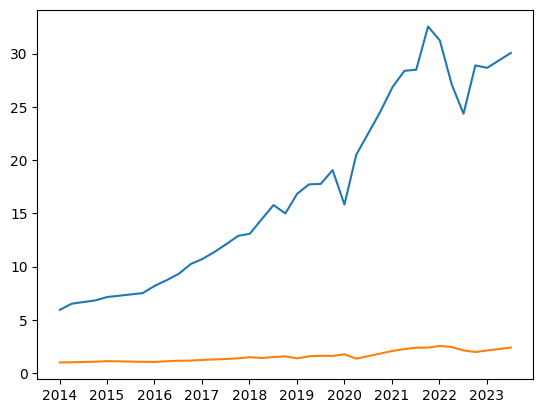

In [124]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [125]:
recommendations = trades.sort_values("date").tail(positions)

In [126]:
recommendations

,date,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
847,2023-10-06 00:00:00+00:00,-0.103814,SPG,Real Estate,102.921227,NaN,2023,4,10,40,4
838,2023-10-06 00:00:00+00:00,0.151398,CHTR,Communication Services,431.160000,NaN,2023,4,10,40,4
839,2023-10-06 00:00:00+00:00,0.151533,BKNG,Consumer Discretionary,3049.440000,NaN,2023,4,10,40,4
840,2023-10-06 00:00:00+00:00,0.038703,COST,Consumer Staples,556.509011,NaN,2023,4,10,40,4
841,2023-10-06 00:00:00+00:00,0.153071,COP,Energy,114.753052,NaN,2023,4,10,40,4
842,2023-10-06 00:00:00+00:00,0.086949,MET,Financials,60.787406,NaN,2023,4,10,40,4
843,2023-10-06 00:00:00+00:00,0.200528,LLY,Health Care,564.176290,NaN,2023,4,10,40,4
844,2023-10-06 00:00:00+00:00,0.106848,CAT,Industrials,264.659353,NaN,2023,4,10,40,4
845,2023-10-06 00:00:00+00:00,0.129415,INTC,Information Technology,36.071188,NaN,2023,4,10,40,4
846,2023-10-06 00:00:00+00:00,0.027592,LIN,Materials,372.386750,NaN,2023,4,10,40,4


In [127]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()